## Overall Workflow

The workflow followed in this notebook is:

1. Load and validate the dataset  
2. Clean the target variable  
3. Separate features and target  
4. Perform exploratory data analysis  
5. Split the data into training and test sets  
6. Preprocess numerical and categorical variables  
7. Train multiple models  
8. Evaluate them using finance-relevant metrics  
9. Compare interpretable and non-linear models  
10. Use explainability methods to understand model behaviour  

This structure ensures that the project is not just a modelling exercise, but a complete and interpretable machine learning pipeline aligned with a credit risk use case.

## Saving Results and Metadata

At the end of the notebook, model performance tables and metadata are exported.

This helps preserve:
- holdout test results
- cross-validation results
- configuration details such as the threshold and feature groups

This is useful for reproducibility, reporting, and later comparison outside the notebook.

In [242]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

In [243]:
# ============================================================
# CONFIG
# ============================================================
BASE_DIR = "/Users/lyndadjellouli/Desktop/Github_Project1"
DATA_PATH = os.path.join(BASE_DIR, "data", "german_credit.csv")

# Results can still be exported as tables/metadata if needed
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2
THRESHOLD = 0.30


# ============================================================
# UTILITIES
# ============================================================

### Figure Display Helper

This helper function is used to display plots neatly inside the notebook.

Its purpose is to keep the notebook readable and avoid repeating display logic after every chart. Instead of saving figures as image files, the notebook uses this function to show them directly inline, which is more suitable for an explanatory, presentation-style workflow.

In [244]:
def display_figure(fig):
    """Display a figure inline in the notebook."""
    fig.tight_layout()
    plt.show()
    plt.close(fig)


### Confusion Matrix Display Function

This function formats and displays a confusion matrix for a given model.

The confusion matrix is especially important in a credit risk setting because it shows:
- how many safe clients were correctly identified
- how many risky clients were correctly detected
- how many risky clients were missed
- how many safe clients were incorrectly flagged

This makes it possible to interpret model performance beyond a single metric such as accuracy.

In [245]:
def show_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Good (0)", "Bad (1)"])
    ax.set_yticklabels(["Good (0)", "Bad (1)"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    display_figure(fig)


### Model Evaluation Function

This function evaluates a trained model using several key classification metrics.

It calculates:
- AUC
- Recall for bad-risk clients
- Precision
- F1-score
- Accuracy
- Confusion matrix values

This is a core function in the notebook because it standardizes evaluation across all models, making comparisons fair and consistent.

In this project, recall for bad clients is especially important because the financial objective is to minimize false negatives, meaning risky clients incorrectly classified as safe.

In [246]:
def evaluate_model(model_name, y_true, y_pred, y_proba):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_proba)

    print(f"\n{'='*70}")
    print(model_name)
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("AUC:", round(auc_score, 4))
    print("Recall (Bad=1):", round(report["1"]["recall"], 4))
    print("Confusion Matrix:\n", cm)

    return {
        "Model": model_name,
        "AUC": auc_score,
        "Recall_Bad": report["1"]["recall"],
        "Precision_Bad": report["1"]["precision"],
        "F1_Bad": report["1"]["f1-score"],
        "Accuracy": report["accuracy"],
        "TN": int(cm[0, 0]),
        "FP": int(cm[0, 1]),
        "FN": int(cm[1, 0]),
        "TP": int(cm[1, 1]),
    }

### Cross-Validation Function

This function performs 5-fold stratified cross-validation on a model.

Its purpose is to provide a more robust estimate of model performance than a single train-test split. Instead of relying on one split alone, the model is evaluated across multiple folds while preserving class balance.

This is important because performance can vary depending on how the data is split. Cross-validation helps confirm whether the observed results are stable and reliable.

In [247]:
def run_cross_validation(name, model, X, y):
    scoring = {
        "auc": "roc_auc",
        "recall_bad": "recall",
        "precision_bad": "precision",
        "f1_bad": "f1",
        "accuracy": "accuracy",
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    return {
        "Model": name,
        "CV_AUC_mean": np.mean(cv_results["test_auc"]),
        "CV_Recall_mean": np.mean(cv_results["test_recall_bad"]),
        "CV_Precision_mean": np.mean(cv_results["test_precision_bad"]),
        "CV_F1_mean": np.mean(cv_results["test_f1_bad"]),
        "CV_Accuracy_mean": np.mean(cv_results["test_accuracy"]),
    }

### Feature Name Extraction Function

After preprocessing, categorical features are transformed through one-hot encoding, which creates multiple new columns.

This function reconstructs the full list of feature names after preprocessing so that model coefficients, feature importances, and SHAP values can be interpreted correctly.

Without this step, explainability outputs would be much harder to read because transformed columns would lose their original meaning.

In [248]:
def get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols):
    cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = cat_encoder.get_feature_names_out(categorical_cols)
    return list(numeric_cols) + list(cat_names)

# ============================================================
# EDA FUNCTIONS
# ============================================================

### Target Distribution Function

This function plots the distribution of the target variable.

It is used to check whether the dataset is balanced or imbalanced. In this project, that step is particularly important because the proportion of good and bad clients directly affects modelling decisions such as class weighting and threshold tuning.

In [249]:
def plot_target_distribution(df, target_col="Risk"):
    fig, ax = plt.subplots(figsize=(6, 4))
    df[target_col].value_counts(dropna=False).plot(kind="bar", ax=ax)
    ax.set_title("Target Distribution")
    ax.set_xlabel("Risk")
    ax.set_ylabel("Count")
    display_figure(fig)

### Missing Values Function

This function visualizes the number of missing values per column.

It helps identify potential data-quality issues before modelling. In this dataset, it highlights that missing values are concentrated in `Saving accounts`, which justifies the decision to treat missing values explicitly during preprocessing.

In [250]:
def plot_missing_values(df):
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if missing.empty:
        return
    fig, ax = plt.subplots(figsize=(7, 4))
    missing.sort_values(ascending=False).plot(kind="bar", ax=ax)
    ax.set_title("Missing Values by Column")
    ax.set_xlabel("Column")
    ax.set_ylabel("Missing count")
    display_figure(fig)

### Numerical Histogram Function

This function plots histograms for numerical variables.

Its purpose is to explore the shape of each distribution, including skewness, concentration, and possible outliers. This is useful for understanding the structure of the data before training any model.

In [251]:
def plot_numeric_histograms(df, numeric_cols):
    for col in numeric_cols:
        fig, ax = plt.subplots(figsize=(6, 4))
        df[col].dropna().plot(kind="hist", bins=20, ax=ax)
        ax.set_title(f"Histogram - {col}")
        ax.set_xlabel(col)
        display_figure(fig)

### Boxplot Function by Risk Class

This function compares the distribution of numerical variables across the two risk classes.

It is particularly useful because it shows whether variables such as Duration or Credit Amount differ between good and bad clients, which can reveal potential predictors of credit risk.

In [252]:
def plot_boxplots_by_risk(df, numeric_cols, target_col="Risk"):
    for col in numeric_cols:
        fig, ax = plt.subplots(figsize=(6, 4))
        df.boxplot(column=col, by=target_col, ax=ax)
        ax.set_title(f"{col} by Risk")
        ax.set_xlabel("Risk")
        ax.set_ylabel(col)
        fig.suptitle("")
        display_figure(fig)

### Categorical Distribution Function by Risk Class

This function plots the distribution of categorical variables across risk groups.

It helps identify whether categories such as Saving Accounts, Housing, or Purpose are associated with different risk profiles. These variables are often especially informative in credit scoring tasks.

In [253]:
def plot_categorical_by_risk(df, categorical_cols, target_col="Risk"):
    for col in categorical_cols:
        ctab = pd.crosstab(df[col], df[target_col], dropna=False)
        fig, ax = plt.subplots(figsize=(8, 4))
        ctab.plot(kind="bar", ax=ax)
        ax.set_title(f"{col} by Risk")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        display_figure(fig)

### Correlation Heatmap Function

This function visualizes the correlation matrix for numerical variables.

It is used to detect relationships between features and to check for possible multicollinearity. In this project, it helps show that Credit Amount and Duration are moderately correlated, which is relevant when interpreting linear models.

In [254]:
def plot_correlation_heatmap(df, numeric_cols):
    corr = df[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.imshow(corr.values)
    ax.set_title("Correlation Heatmap (Numeric Variables)")
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
    ax.set_yticklabels(numeric_cols)

    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center")

    display_figure(fig)

# ============================================================
# EXPLAINABILITY FUNCTIONS
# ============================================================

### Logistic Regression Coefficient Function

This function extracts and visualizes the largest coefficients from the class-weighted logistic regression model.

The goal is to interpret which features increase or decrease the probability of bad credit risk:
- positive coefficients increase predicted risk
- negative coefficients reduce predicted risk

This makes logistic regression especially useful as an interpretable benchmark in financial modelling.

In [255]:
def plot_logistic_coefficients(fitted_pipeline, numeric_cols, categorical_cols, top_n=15):
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    classifier = fitted_pipeline.named_steps["classifier"]

    feature_names = get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols)
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": classifier.coef_[0]
    })
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

    coef_df.to_csv(os.path.join(RESULTS_DIR, "logistic_regression_coefficients.csv"), index=False)

    top_df = coef_df.head(top_n).sort_values("coefficient")
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top_df["feature"], top_df["coefficient"])
    ax.set_title("Top Logistic Regression Coefficients")
    ax.set_xlabel("Coefficient")
    display_figure(fig)

### Tree-Based Feature Importance Function

This function plots the top feature importances for tree-based models such as Random Forest and XGBoost.

Feature importance indicates how much each variable contributes to the predictive performance of the model.

This is useful because it highlights the main drivers of credit risk in non-linear models, where standard coefficients are not available.

In [256]:
def plot_tree_feature_importance(fitted_pipeline, model_name, filename_csv, numeric_cols, categorical_cols, top_n=10):
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    classifier = fitted_pipeline.named_steps["classifier"]
    feature_names = get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols)

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": classifier.feature_importances_
    }).sort_values("importance", ascending=False)

    importance_df.to_csv(os.path.join(RESULTS_DIR, filename_csv), index=False)

    top_df = importance_df.head(top_n).sort_values("importance")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(top_df["feature"], top_df["importance"])
    ax.set_title(f"Top {top_n} {model_name} Feature Importances")
    ax.set_xlabel("Importance")
    display_figure(fig)

### SHAP Explainability Function

This function generates SHAP explanations for tree-based models.

It creates two plots:
- a SHAP summary bar plot, which shows global feature importance
- a SHAP summary beeswarm plot, which shows how feature values influence predictions

This is particularly valuable in financial applications because it adds transparency to complex models and helps explain why the model classifies certain applicants as risky.

In [257]:
def plot_shap_tree(fitted_pipeline, model_name, X_test, numeric_cols, categorical_cols):
    import shap

    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    classifier = fitted_pipeline.named_steps["classifier"]
    feature_names = get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols)
    X_test_transformed = preprocessor.transform(X_test)

    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_test_transformed)

    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1]
    else:
        shap_values_to_plot = shap_values

    plt.figure()
    shap.summary_plot(
        shap_values_to_plot,
        X_test_transformed,
        feature_names=feature_names,
        plot_type="bar",
        show=False
    )
    plt.title(f"SHAP Summary Bar - {model_name}")
    plt.tight_layout()
    plt.show()
    plt.close()

    plt.figure()
    shap.summary_plot(
        shap_values_to_plot,
        X_test_transformed,
        feature_names=feature_names,
        show=False
    )
    plt.title(f"SHAP Summary - {model_name}")
    plt.tight_layout()
    plt.show()
    plt.close()


# ============================================================
# LOAD + CLEAN DATA
# ============================================================

## Loading the Dataset

The dataset is loaded using `pandas.read_csv`, with `"NA"` explicitly treated as missing values.

This is an important data-quality step because some missing entries in the dataset might otherwise be interpreted as plain text rather than actual missing values. Treating them correctly ensures that missingness can be handled properly during preprocessing.

### Removing Unnecessary Columns

The notebook removes the column `Unnamed: 0` if it exists.

This type of column often appears when a dataset has been saved with an index column by mistake. It does not contain meaningful predictive information, so it is safely dropped.

In [258]:
df = pd.read_csv(DATA_PATH, na_values=["NA"])
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("\nDataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())

if "Risk" not in df.columns:
    raise ValueError("The dataset must contain a 'Risk' column.")

df["Risk"] = df["Risk"].astype(str).str.strip().str.lower()
df = df[df["Risk"].isin(["good", "bad"])].copy()

eda_df = df.copy()
df["Risk"] = df["Risk"].map({"good": 0, "bad": 1})

X = df.drop("Risk", axis=1)
y = df["Risk"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Dataset shape: (1000, 10)
Duplicate rows: 0

Data types:
 Credit History      int64
Age                 int64
Gender             object
Job                 int64
Housing            object
Saving accounts    object
Credit amount       int64
Duration            int64
Purpose            object
Risk               object
dtype: object

Missing values:
 Credit History       0
Age                  0
Gender               0
Job                  0
Housing              0
Saving accounts    183
Credit amount        0
Duration             0
Purpose              0
Risk                 0
dtype: int64

Categorical columns: ['Gender', 'Housing', 'Saving accounts', 'Purpose']
Numeric columns: ['Credit History', 'Age', 'Job', 'Credit amount', 'Duration']


# ============================================================
# EDA
# ============================================================

### Target Distribution

Before training any model, it is essential to understand the distribution of the target variable.

In this dataset, the target represents credit risk:
- Good (0)
- Bad (1)

This plot shows the number of applicants in each class and helps identify potential class imbalance.

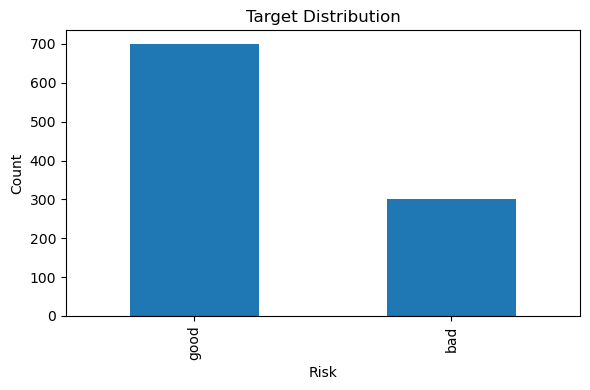

In [259]:
plot_target_distribution(eda_df)

The dataset is imbalanced, with approximately 70% good clients and 30% bad clients.

This imbalance is critical for modelling because:
- A model may achieve high accuracy by simply predicting the majority class
- However, this would result in poor detection of risky clients

This justifies the use of:
- class weighting
- threshold tuning

in later stages of the modelling process.

> We prioritize recall to minimize false negatives, meaning risky clients incorrectly classified as safe.

# ----------------------- #

### Missing Values Analysis

This plot shows the number of missing values per feature.

Understanding missing data is important in financial datasets, as missingness itself can carry information about a client's financial profile.

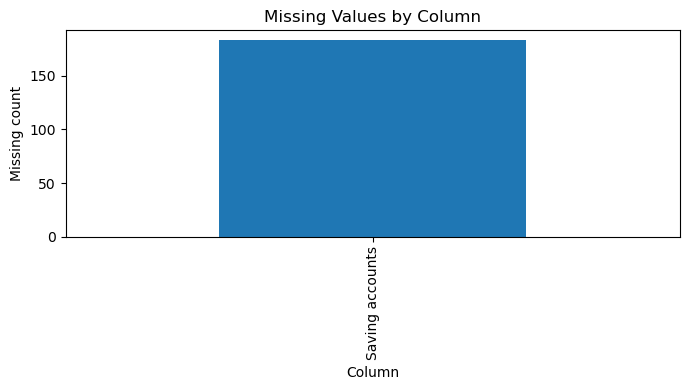

In [260]:
plot_missing_values(df)

Only one feature contains missing values: `Saving accounts`.

Rather than dropping these rows, missing values are treated explicitly by:
- imputing a new category: "missing"

This is a realistic approach in financial modelling because:
- missing financial information may itself indicate risk
- removing rows could reduce dataset size unnecessarily

This ensures that all observations are preserved while still capturing useful signals.

# ----------------------- #

### Distribution of Numerical Variables

Histograms are used to understand the distribution of numerical features such as Age, Credit Amount, Duration, and Credit History.

This helps identify skewness, concentration, and potential outliers before modelling.

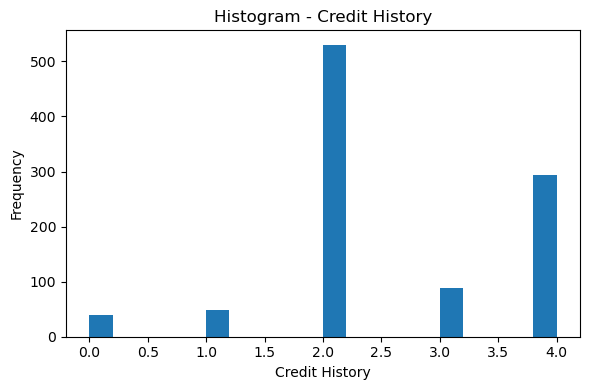

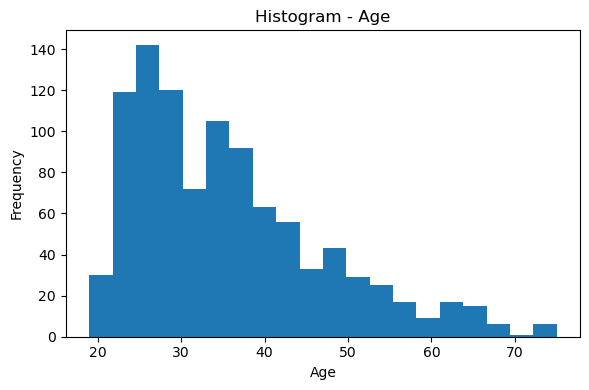

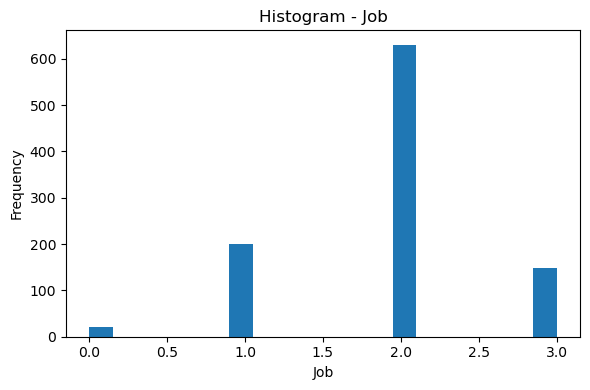

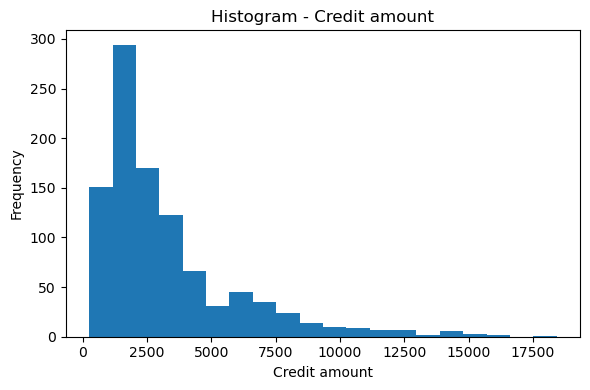

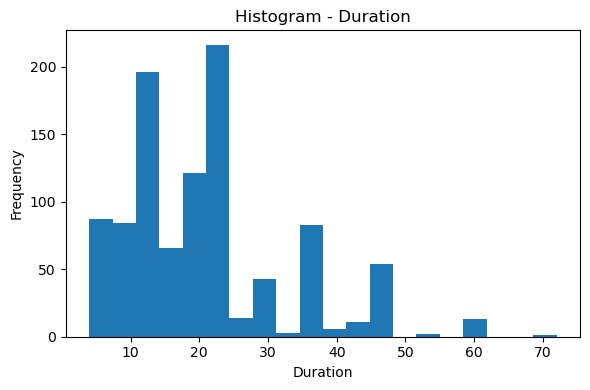

In [261]:
plot_numeric_histograms(df, numeric_cols)

The numerical variables show several important patterns:

- **Credit amount** and **Duration** are right-skewed, with a small number of large values
- **Age** is concentrated in younger ranges
- **Credit History** and **Job** behave more like categorical variables despite being numeric

These observations are important because:
- skewed variables may influence model behaviour
- extreme values may contribute to risk
- some numeric variables may require cautious interpretation

These insights support the use of both linear and non-linear models.

# ----------------------- #

### Numerical Features by Risk Class

Boxplots allow us to compare the distribution of numerical variables between good and bad credit risk groups.

This helps identify features that may separate the two classes.

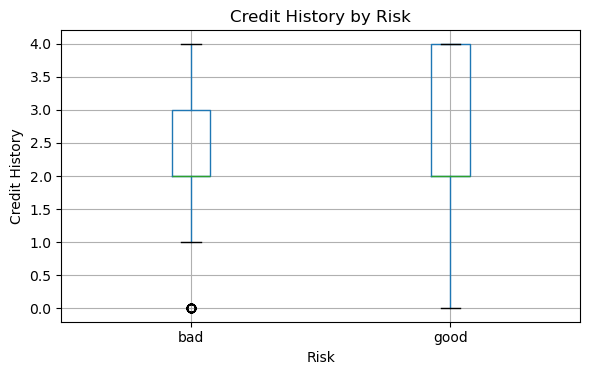

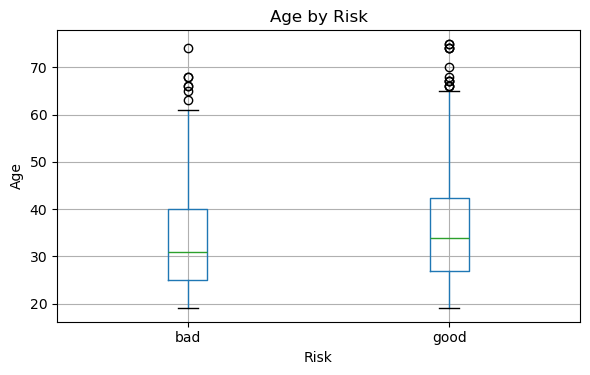

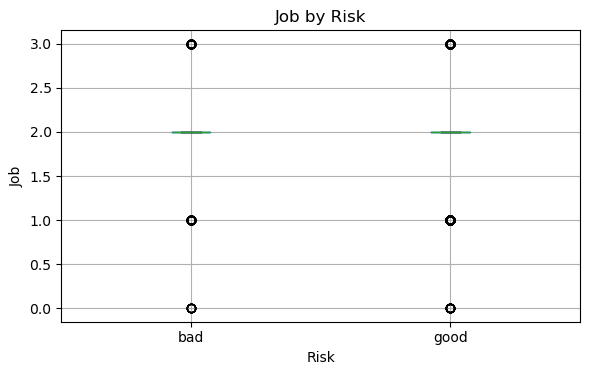

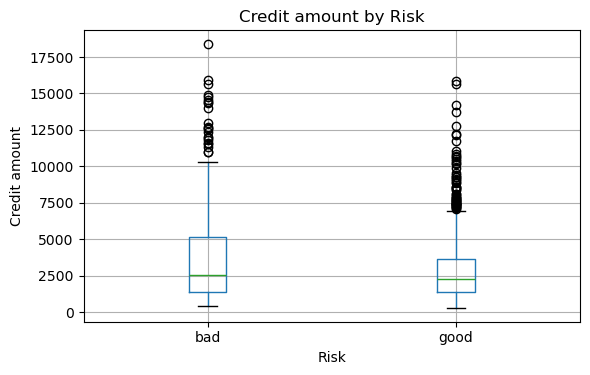

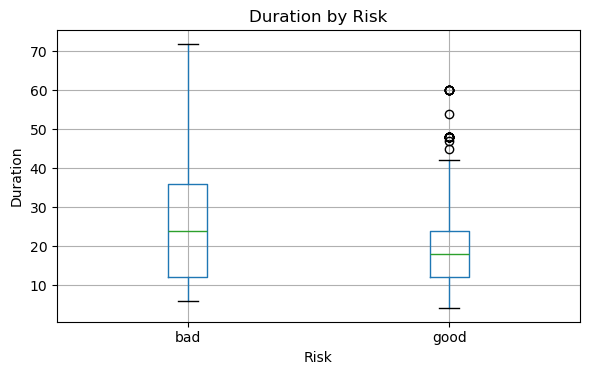

In [262]:
plot_boxplots_by_risk(eda_df, numeric_cols, target_col="Risk")

The boxplots reveal several key insights:

- **Duration** is clearly higher for bad-risk clients  
  → Longer loans increase uncertainty and default risk

- **Credit amount** shows more extreme values for bad clients  
  → Larger loans increase exposure

- **Age** shows only weak separation  
  → Not a dominant predictor alone

- **Credit History** shows slight differences  
  → More useful in combination with other features

These findings are consistent with real-world credit risk logic and support the inclusion of these variables in the model.

# ----------------------- #

### Categorical Features by Risk Class

These plots show how categorical variables such as Gender, Housing, Purpose, and Saving Accounts are distributed across risk classes.

They provide insight into how different customer profiles relate to credit risk.

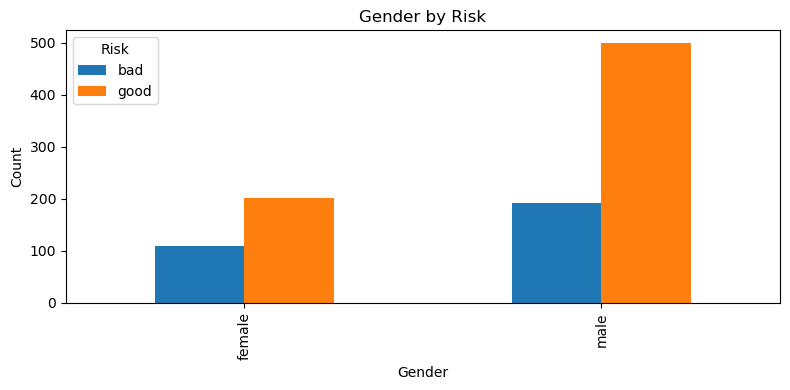

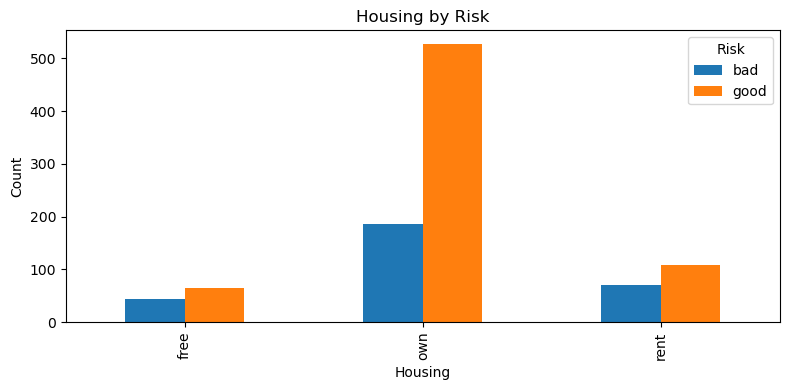

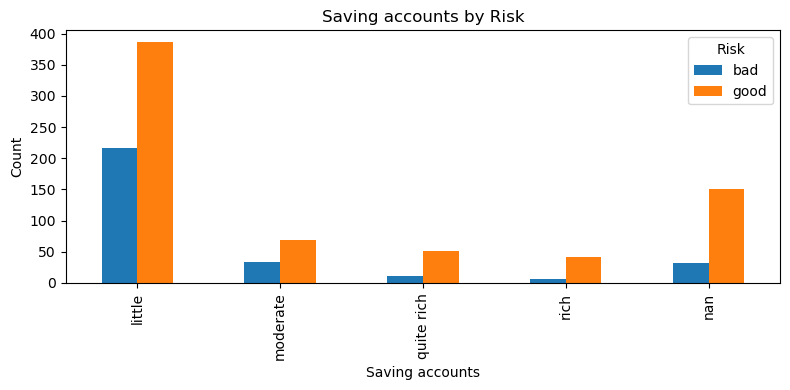

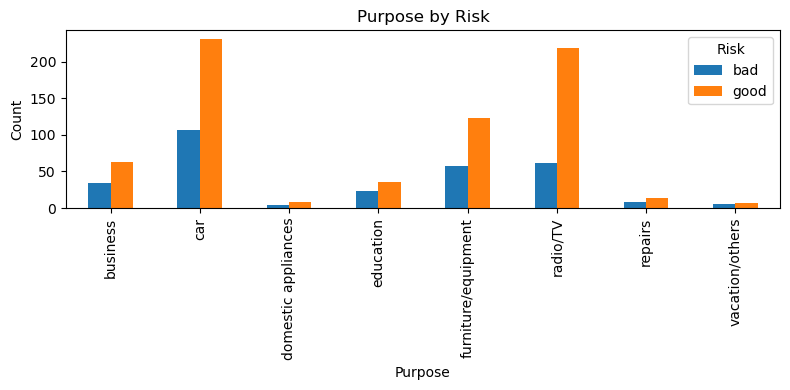

In [263]:

plot_categorical_by_risk(eda_df, categorical_cols, target_col="Risk")

The categorical variables provide useful segmentation insights:

- **Saving accounts** is particularly informative:
  - lower savings → higher risk tendency

- **Housing**:
  - ownership appears more stable
  - renting may indicate higher variability

- **Purpose**:
  - certain loan purposes show different risk patterns

- **Gender**:
  - distribution differences exist but should be interpreted cautiously

These variables are especially valuable for tree-based models, which can capture complex interactions.

# ----------------------- #

### Correlation Analysis

This heatmap shows the correlation between numerical variables.

It helps identify relationships between features and potential multicollinearity.

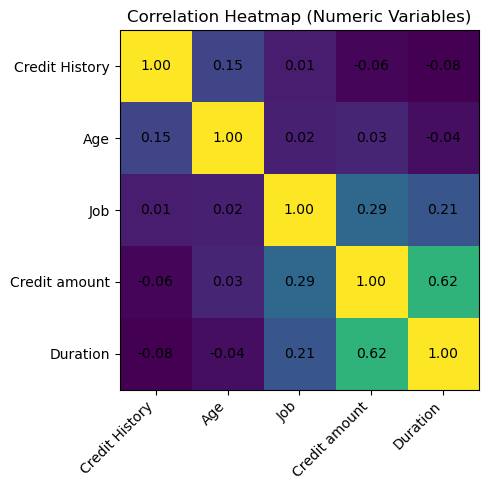

In [264]:
plot_correlation_heatmap(df, numeric_cols)

The strongest correlation is observed between:

- Credit amount and Duration (~0.62)

This indicates that:
- larger loans tend to have longer durations

This is important because:
- it may affect linear models such as Logistic Regression
- tree-based models (Random Forest, XGBoost) handle this better

This helps explain why non-linear models slightly outperform logistic regression in this project.

# ----------------------- #

### The results are saved in csv files 

In [265]:
df[numeric_cols].describe().T.to_csv(os.path.join(RESULTS_DIR, "eda_numeric_summary.csv"))
df.isna().sum().to_csv(os.path.join(RESULTS_DIR, "eda_missing_values_summary.csv"))

# ============================================================
# SPLIT
# ============================================================

## Train-Test Split

The data is split into training and test sets using a stratified 80/20 split.

Stratification is important because it preserves the proportion of good and bad clients in both sets. This makes evaluation more reliable, especially in an imbalanced classification problem.

An 80/20 split is used as a standard compromise between:
- providing enough data for training
- keeping a meaningful holdout test set for evaluation

In [266]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# ============================================================
# PREPROCESSOR
# ============================================================

### Numerical Preprocessing

Numerical features are preprocessed using:
- median imputation
- standard scaling

Median imputation is robust to skewed values and outliers, while scaling ensures that variables are placed on comparable ranges, which is particularly important for logistic regression.

In [267]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### Categorical Preprocessing

Categorical features are preprocessed using:
- imputation with the label `"missing"`
- one-hot encoding

This approach is more appropriate than applying label encoding to all text columns because it preserves the categorical structure of the variables without introducing artificial numeric order.

In [268]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

### Combined Preprocessing Pipeline

The `ColumnTransformer` applies numerical and categorical preprocessing in one unified pipeline.

This is a strong and professional design choice because it:
- keeps preprocessing reproducible
- avoids train-test leakage
- ensures that the same transformations are applied consistently across all models

In [269]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# ============================================================
# MODELS
# ============================================================

## Model 1 — Baseline Logistic Regression

This model serves as the simplest interpretable benchmark.

It is useful because:
- it provides a clear baseline for comparison
- it is easy to interpret
- it helps identify whether more complex models are actually adding value

However, in an imbalanced credit risk setting, a baseline logistic model may favor the majority class and fail to detect enough risky clients.

## Model 2 — Class-Weighted Logistic Regression

This model extends the baseline logistic regression by applying class weighting.

Its purpose is to give more importance to the minority class (bad-risk clients), which helps improve recall for risky applicants.

This is a more finance-aware version of logistic regression because it better reflects the business cost of missing a risky client.

## Model 4 — Random Forest

Random Forest is introduced as a non-linear ensemble model.

It is useful because it:
- captures interactions between variables
- handles non-linear relationships
- is robust and relatively interpretable through feature importance

In this project, Random Forest provides a stronger predictive balance than logistic regression while still remaining reasonably interpretable.

In [270]:
models = {
    "Model 1 - Baseline Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]),
    "Model 2 - Class Weighted Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),
    "Model 4 - Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample"
        ))
    ])
}

## Model 5 — XGBoost

XGBoost is included as the strongest predictive model in the notebook.

It is particularly effective for structured tabular data because it:
- captures non-linear patterns
- handles interactions efficiently
- often achieves strong predictive performance

In this project, XGBoost delivers the best overall performance and is the strongest candidate for a production-style credit risk model.

In [271]:
xgb_available = False
try:
    models["Model 5 - XGBoost"] = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            eval_metric="logloss"
        ))
    ])
    xgb_available = True
except Exception:
    pass

# ============================================================
# FIT + EVALUATE
# ============================================================

### Confusion Matrix Analysis

Confusion matrices provide a detailed breakdown of model predictions:

- True Positives (TP): correctly identified bad clients
- False Negatives (FN): risky clients missed by the model
- False Positives (FP): safe clients incorrectly flagged
- True Negatives (TN): correctly identified safe clients

This is the most important tool for understanding model behaviour in a financial context.


Model 1 - Baseline Logistic Regression
              precision    recall  f1-score   support

           0       0.78      0.92      0.84       140
           1       0.68      0.38      0.49        60

    accuracy                           0.76       200
   macro avg       0.73      0.65      0.67       200
weighted avg       0.75      0.76      0.74       200

AUC: 0.687
Recall (Bad=1): 0.3833
Confusion Matrix:
 [[129  11]
 [ 37  23]]


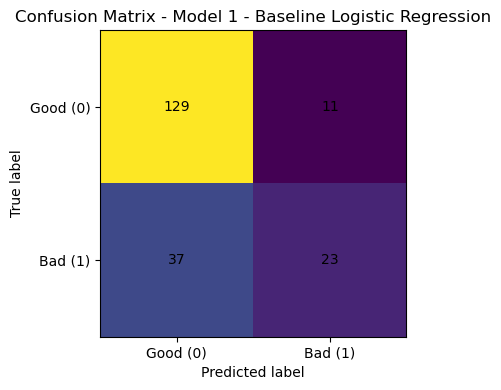


Model 2 - Class Weighted Logistic Regression
              precision    recall  f1-score   support

           0       0.78      0.65      0.71       140
           1       0.42      0.58      0.49        60

    accuracy                           0.63       200
   macro avg       0.60      0.62      0.60       200
weighted avg       0.67      0.63      0.64       200

AUC: 0.6882
Recall (Bad=1): 0.5833
Confusion Matrix:
 [[91 49]
 [25 35]]


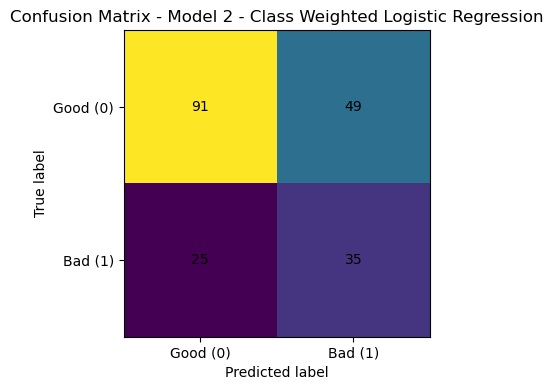


Model 4 - Random Forest
              precision    recall  f1-score   support

           0       0.79      0.80      0.79       140
           1       0.52      0.50      0.51        60

    accuracy                           0.71       200
   macro avg       0.65      0.65      0.65       200
weighted avg       0.71      0.71      0.71       200

AUC: 0.7163
Recall (Bad=1): 0.5
Confusion Matrix:
 [[112  28]
 [ 30  30]]


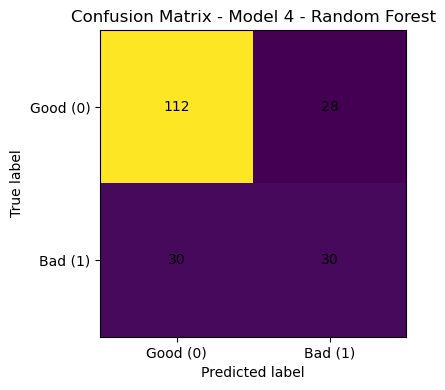


Model 5 - XGBoost
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       140
           1       0.56      0.50      0.53        60

    accuracy                           0.73       200
   macro avg       0.68      0.66      0.67       200
weighted avg       0.72      0.73      0.73       200

AUC: 0.7354
Recall (Bad=1): 0.5
Confusion Matrix:
 [[116  24]
 [ 30  30]]


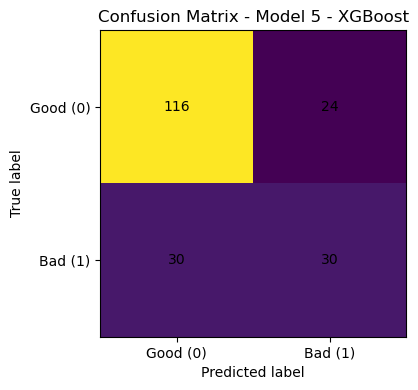

In [272]:
results = []
cv_results = {}
probas = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append(evaluate_model(model_name, y_test, y_pred, y_proba))
    cv_results[model_name] = run_cross_validation(model_name, model, X, y)
    probas[model_name] = y_proba

    show_confusion_matrix(
        confusion_matrix(y_test, y_pred),
        f"Confusion Matrix - {model_name}"
    )

## Model 3 — Threshold-Tuned Logistic Regression

This model uses the probabilities from the class-weighted logistic regression model but changes the classification threshold from the default 0.5 to 0.3.

The goal is to detect more risky clients by making the model more sensitive.

This is an important decision strategy in credit risk modelling because:
- lower threshold → higher recall
- but also → more false positives

This makes the model useful as a screening tool when the priority is to avoid missing high-risk applicants.


Model 3 - Class Weighted Logistic Regression + Threshold 0.3
              precision    recall  f1-score   support

           0       0.89      0.28      0.42       140
           1       0.35      0.92      0.51        60

    accuracy                           0.47       200
   macro avg       0.62      0.60      0.47       200
weighted avg       0.73      0.47      0.45       200

AUC: 0.6882
Recall (Bad=1): 0.9167
Confusion Matrix:
 [[ 39 101]
 [  5  55]]


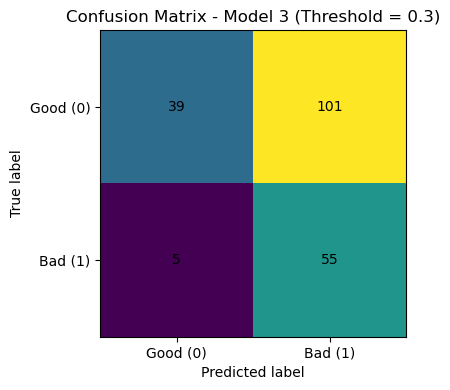

In [273]:
# Threshold model
threshold_model = models["Model 2 - Class Weighted Logistic Regression"]
y_proba_threshold = threshold_model.predict_proba(X_test)[:, 1]
y_pred_threshold = (y_proba_threshold >= THRESHOLD).astype(int)

results.append(evaluate_model(
    f"Model 3 - Class Weighted Logistic Regression + Threshold {THRESHOLD}",
    y_test, y_pred_threshold, y_proba_threshold
))
probas[f"Model 3 - Class Weighted Logistic Regression + Threshold {THRESHOLD}"] = y_proba_threshold

show_confusion_matrix(
    confusion_matrix(y_test, y_pred_threshold),
    f"Confusion Matrix - Model 3 (Threshold = {THRESHOLD})"
)

The confusion matrices reveal the core trade-offs between models:

- The baseline model is conservative and misses many risky clients
- Class weighting improves detection of bad clients
- Threshold tuning maximizes detection but creates many false positives
- Random Forest and XGBoost provide the best overall balance

This reinforces a key insight:

Model evaluation must consider business impact, not just accuracy.

# ============================================================
# EXPLAINABILITY
# ============================================================

### Logistic Regression Coefficients

This plot shows the most influential features in the class-weighted logistic regression model.

Positive coefficients increase the probability of being classified as bad risk, while negative coefficients decrease it.

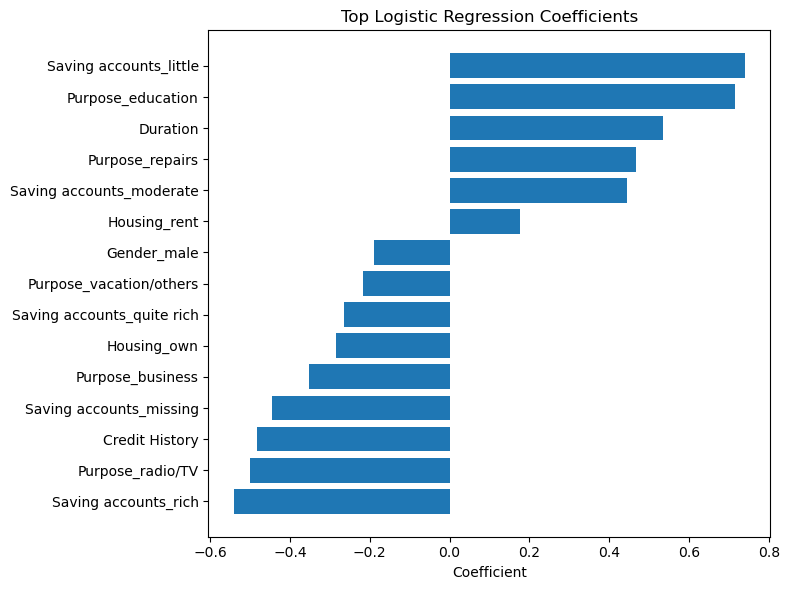

In [274]:
plot_logistic_coefficients(models["Model 2 - Class Weighted Logistic Regression"], numeric_cols, categorical_cols, top_n=15)

The most influential features include:

- **Duration** → increases risk  
- **Saving accounts (little / moderate)** → increases risk  
- **Purpose (education, repairs)** → associated with higher risk  

Features reducing risk include:

- **Saving accounts (rich)**  
- **Housing (own)**  
- **Credit History (stronger values)**  

These findings are consistent with financial intuition:

- Longer loans → higher uncertainty  
- Lower savings → weaker financial stability  
- Stronger financial profiles → lower default probability  

Logistic regression provides clear interpretability, making it valuable for financial decision-making.

# ----------------------- #

### Random Forest Feature Importance

This plot shows the most important features used by the Random Forest model.

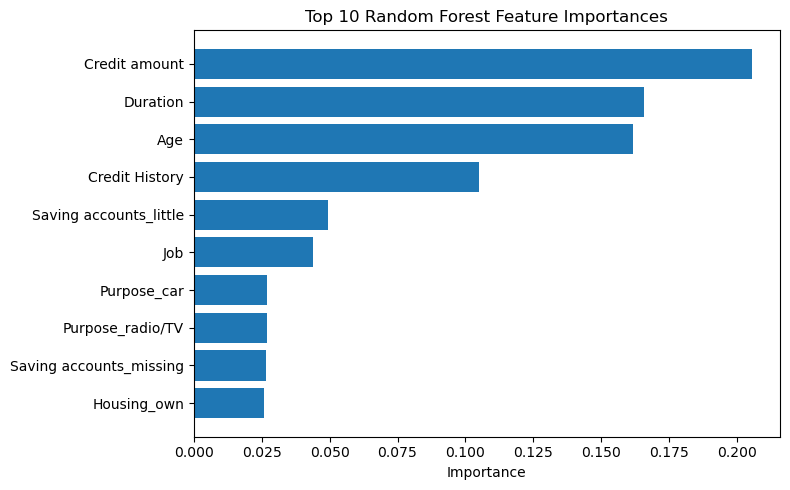

In [275]:
plot_tree_feature_importance(models["Model 4 - Random Forest"], "Random Forest", "rf_feature_importance.csv", numeric_cols, categorical_cols)

The top features are:

- Credit amount  
- Duration  
- Age  
- Credit History  

These results confirm key risk drivers:

- Larger loans increase exposure  
- Longer durations increase uncertainty  
- Credit history reflects repayment behaviour  

Random Forest captures non-linear relationships and interactions, which explains its improved performance over logistic regression.

# ----------------------- #

### XGBoost Feature Importance

This plot shows feature importance based on the XGBoost model.

### SHAP Summary (XGBoost - Bar)

This plot shows the global importance of features in the XGBoost model.

### SHAP Summary (XGBoost - Detailed)

This plot shows how feature values influence predictions.

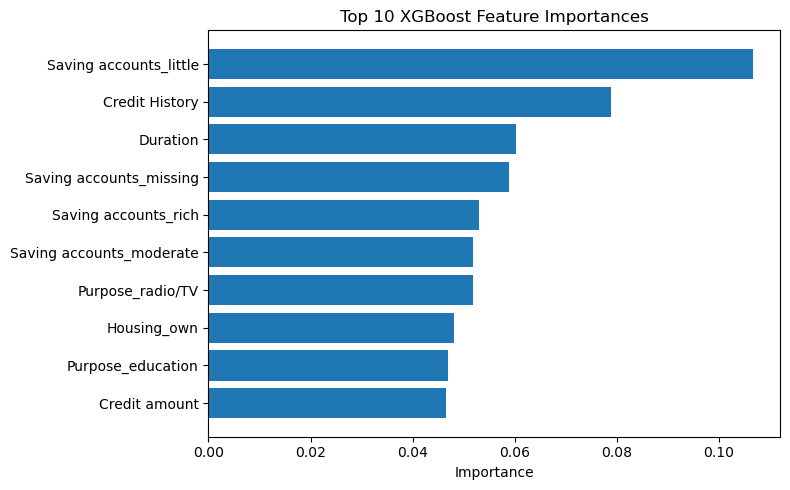

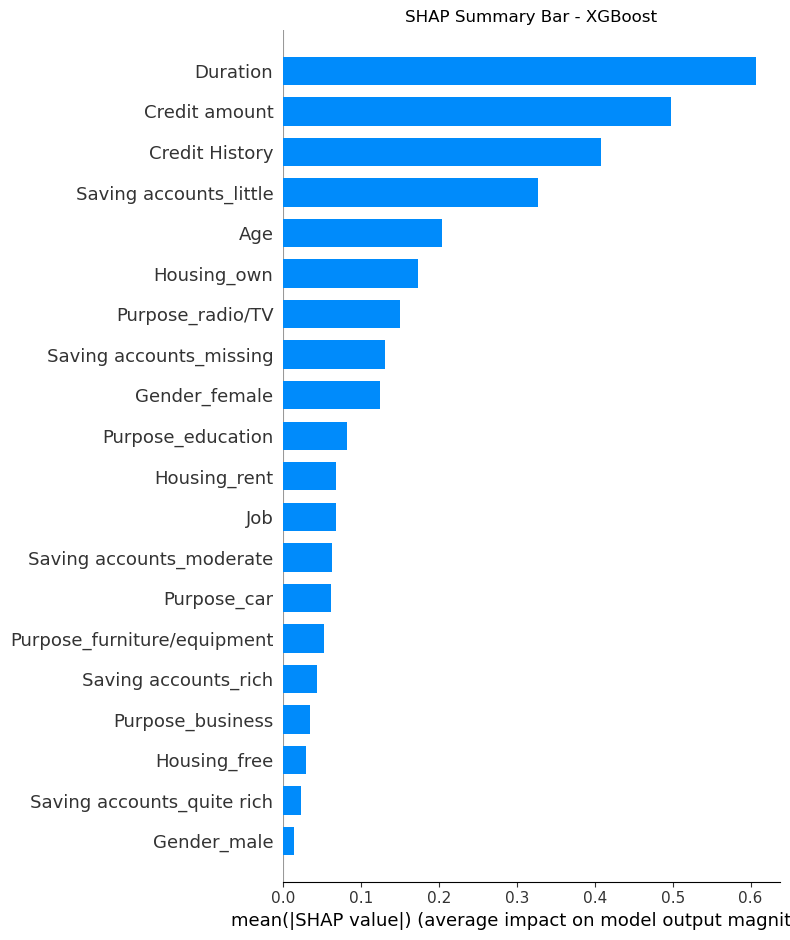

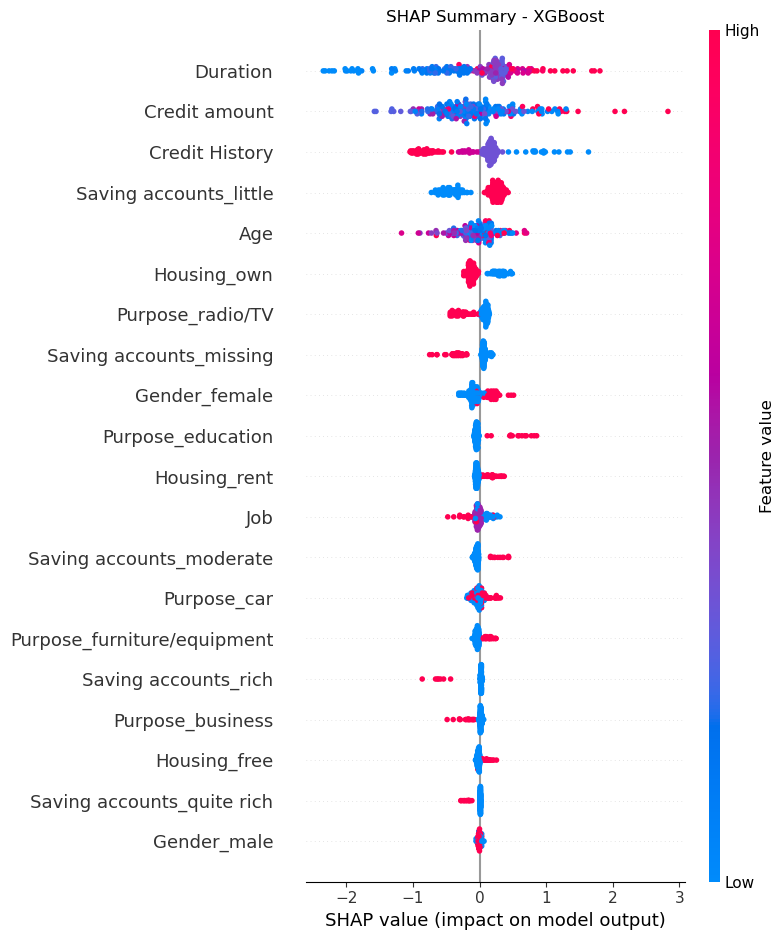

In [276]:
if xgb_available:
    plot_tree_feature_importance(models["Model 5 - XGBoost"], "XGBoost", "xgb_feature_importance.csv", numeric_cols, categorical_cols)

    try:
        plot_shap_tree(models["Model 5 - XGBoost"], "XGBoost", X_test, numeric_cols, categorical_cols)
    except Exception as e:
        print("XGBoost SHAP failed:", e)

XGBoost features importance highlights:

- Saving accounts (all categories)  
- Credit History  
- Duration  
- Credit amount  

Compared to Random Forest, XGBoost places more emphasis on financial behaviour (savings)

This suggests that:
- both financial capacity (savings)
- and loan structure (amount, duration)

jointly influence risk predictions.

This makes XGBoost particularly effective for credit scoring tasks.

# ------------ #

The most important features globally are:

- Duration  
- Credit amount  
- Credit History  
- Saving accounts  

This confirms that the model is learning meaningful financial patterns.

The bar plot provides a simplified overview of feature importance across the dataset.

# ------------ # 

The SHAP plot for XGBoost provides deeper insight into model behaviour:

- High **Duration** → increases risk  
- High **Credit amount** → increases risk  
- Low **Saving accounts** → increases risk  
- Strong **Credit History** → reduces risk  

The colour gradient shows feature values:
- Red = high value  
- Blue = low value  

This plot is extremely valuable because it shows:
- which features matter
- how they affect predictions

This level of interpretability is critical in financial applications.

# ----------------------- #

### SHAP Summary (Random Forest - Bar)

This plot shows global feature importance for the Random Forest model.

### SHAP Summary (Random Forest - Detailed)

This plot shows how features influence predictions in the Random Forest model.

<Figure size 640x480 with 0 Axes>

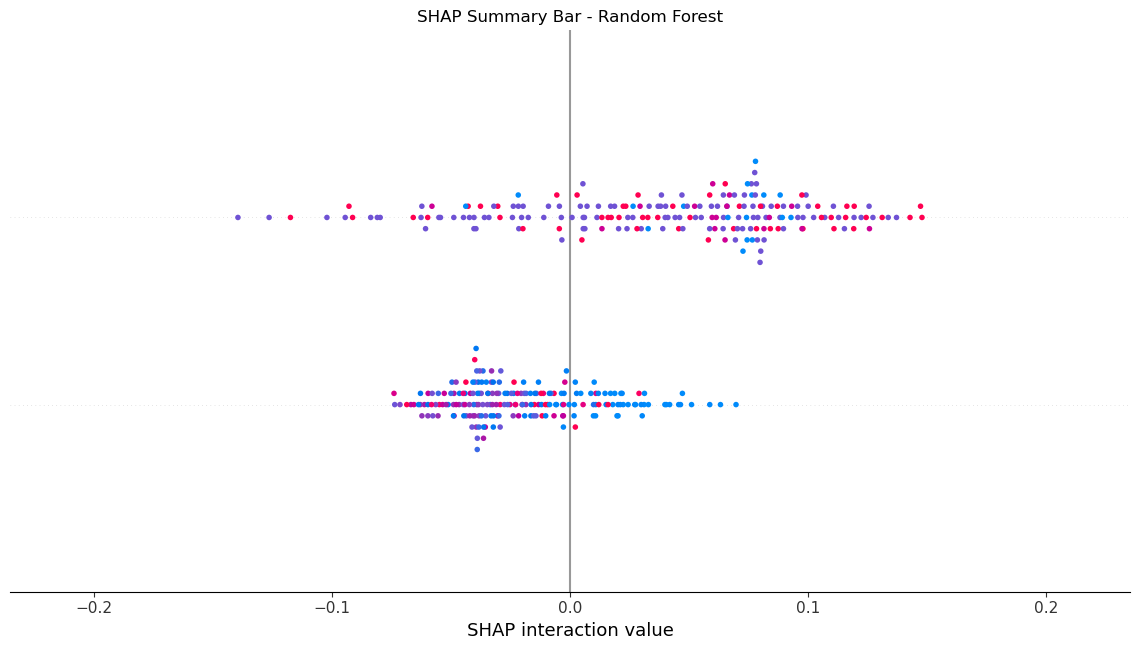

<Figure size 640x480 with 0 Axes>

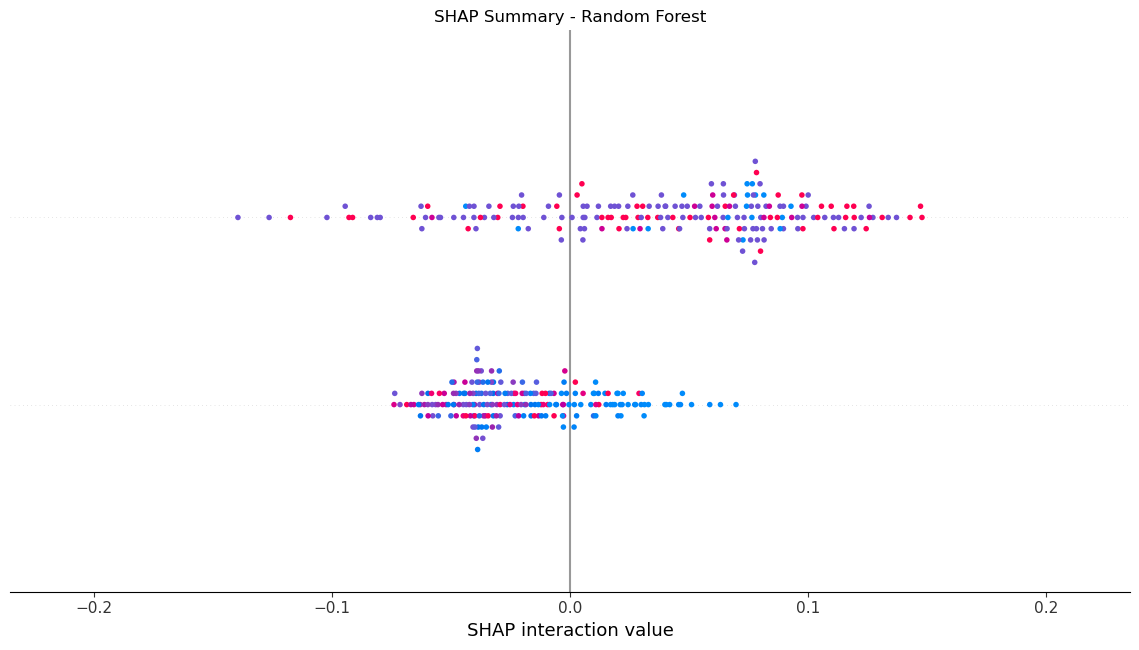

In [277]:
try:
    plot_shap_tree(models["Model 4 - Random Forest"], "Random Forest", X_test, numeric_cols, categorical_cols)
except Exception as e:
    print("Random Forest SHAP failed:", e)

The Random Forest SHAP bar confirms similar key drivers:

- Credit amount  
- Duration  
- Age  
- Credit History  

This consistency across models increases confidence in the results.

# ------------ # 

The SHAP distribution confirms:

- Higher duration increases risk  
- Larger credit amounts increase risk  
- Age has a smaller effect  
- Credit history contributes in both directions  

Compared to XGBoost, the patterns are similar but slightly less sharp.

This is expected because:
- XGBoost is a more optimized model
- Random Forest is more averaged and less sensitive

# ------------ # 

### FINAL INSIGHT

cross all models and explainability methods, consistent risk drivers emerge:

- Duration  
- Credit amount  
- Saving accounts  
- Credit history  

This consistency strengthens confidence in the model and supports its use in financial decision-making.

It shows that the model is not only predictive, but also aligned with real-world credit risk logic.

# ============================================================
# COMPARISON PLOTS
# ============================================================

### ROC Curve Comparison

The ROC curve evaluates how well each model separates good and bad clients across all thresholds.

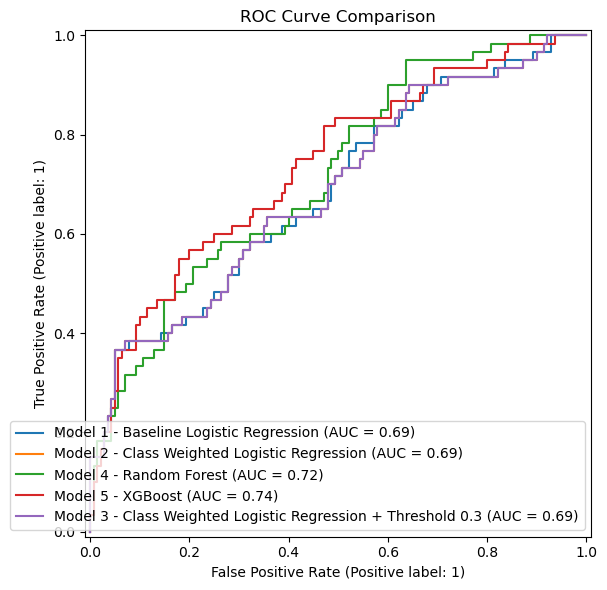

In [278]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, y_proba in probas.items():
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name=name)
ax.set_title("ROC Curve Comparison")
display_figure(fig)

XGBoost achieves the highest AUC, indicating the best overall ranking ability.

Random Forest also performs well, while logistic models are slightly weaker.

This suggests that non-linear models better capture complex relationships in the data.

# ----------------------- #

### Precision-Recall Curve

This curve is particularly important for imbalanced datasets, as it focuses on performance for the minority class (bad clients).

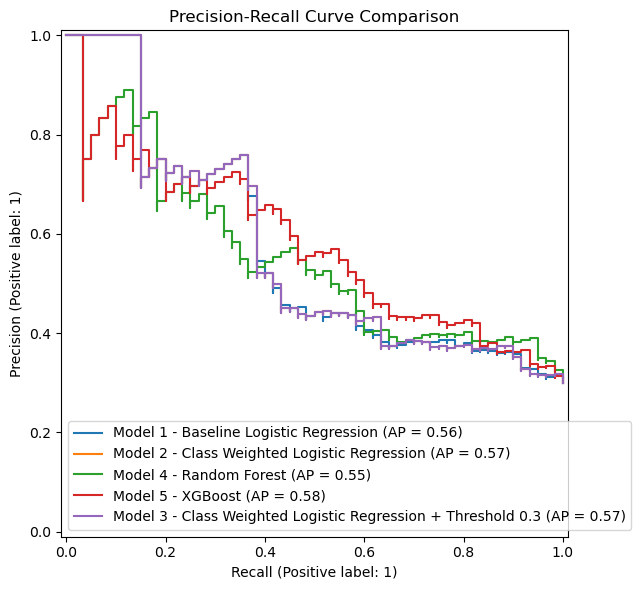

In [279]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, y_proba in probas.items():
    PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax, name=name)
ax.set_title("Precision-Recall Curve Comparison")
display_figure(fig)

The curve highlights the trade-off between precision and recall:

- Increasing recall reduces missed risky clients
- But increases false positives

XGBoost maintains the best balance overall.

# ----------------------- #

### Threshold Tuning Analysis

In a credit risk setting, the default classification threshold of 0.5 is not always appropriate. Lowering the threshold allows the model to classify more applicants as high-risk, which increases the detection of bad clients (recall), but also increases false positives.

This section explores how recall, precision, and F1-score evolve as the classification threshold changes. This helps illustrate the trade-off between risk sensitivity and decision accuracy.

In [280]:
thresholds = np.arange(0.10, 0.91, 0.05)
recalls, precisions, f1_scores = [], [], []

for t in thresholds:
    preds = (y_proba_threshold >= t).astype(int)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    recalls.append(report["1"]["recall"])
    precisions.append(report["1"]["precision"])
    f1_scores.append(report["1"]["f1-score"])

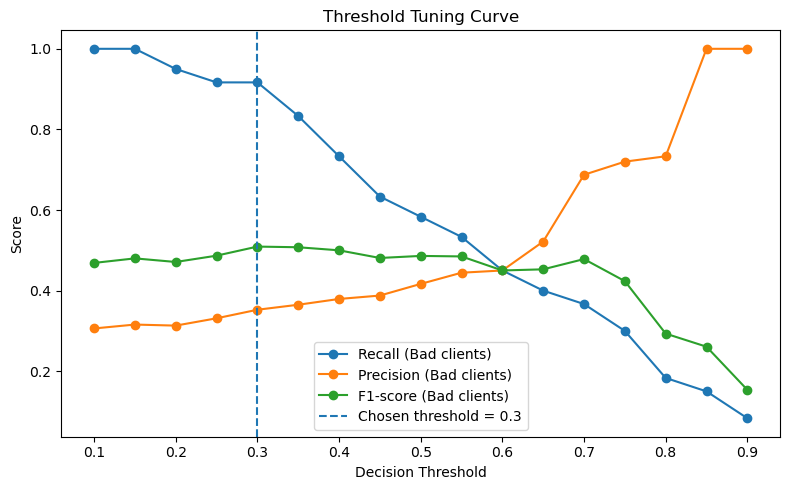

In [281]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, recalls, marker="o", label="Recall (Bad clients)")
ax.plot(thresholds, precisions, marker="o", label="Precision (Bad clients)")
ax.plot(thresholds, f1_scores, marker="o", label="F1-score (Bad clients)")
ax.axvline(THRESHOLD, linestyle="--", label=f"Chosen threshold = {THRESHOLD}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Tuning Curve")
ax.legend()
display_figure(fig)

The threshold tuning curve clearly illustrates the trade-off between recall and precision:

- As the threshold decreases, **recall increases sharply**, meaning the model detects more bad-risk clients.
- However, **precision decreases**, indicating that more good clients are incorrectly classified as risky.
- Around the chosen threshold of 0.3, recall becomes very high, which aligns with a risk-sensitive strategy, meaning the model becomes more aggressive in flagging risk.

This directly reflects a key principle in financial risk modelling:

We prioritize recall to minimize false negatives (In other terms, risky clients incorrectly classified as safe).

At this threshold, the model becomes highly effective as a **screening tool**, ensuring that most risky applicants are identified, even if it leads to a higher number of false positives. However, this comes with a large number of false positives.

This demonstrates that model performance must be interpreted in the context of business objectives, rather than relying on a single metric.

# ------------ # 

### Threshold-Based Decision Rule

After training the class-weighted logistic regression model, predicted probabilities are converted into class labels using a threshold of 0.3 instead of 0.5.

This does not change the model itself, but it changes the decision rule.

This is useful because in finance, the operating threshold can be adjusted depending on business priorities. A lower threshold increases sensitivity to bad-risk clients, which reduces false negatives but increases false positives.

# ============================================================
# SAVE TABLES
# ============================================================

### Model Performance Comparison

This chart compares all models across key evaluation metrics on the holdout test set, including AUC, recall, precision, F1-score, and accuracy.

Rather than focusing on a single “best” model, the goal is to understand how each model performs under different evaluation criteria, especially in relation to credit risk detection.

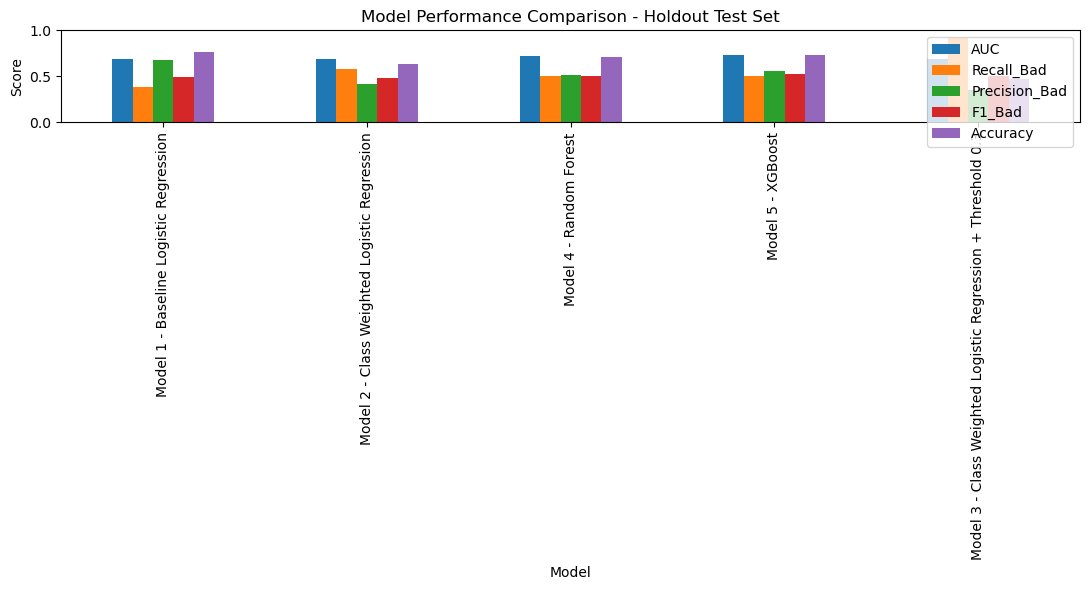


Notebook run completed successfully


In [282]:
results_df = pd.DataFrame(results)
cv_results_df = pd.DataFrame(list(cv_results.values()))

results_df.to_csv(os.path.join(RESULTS_DIR, "model_results_holdout.csv"), index=False)
cv_results_df.to_csv(os.path.join(RESULTS_DIR, "model_results_cross_validation.csv"), index=False)

metrics_plot_df = results_df[["Model", "AUC", "Recall_Bad", "Precision_Bad", "F1_Bad", "Accuracy"]].set_index("Model")
fig, ax = plt.subplots(figsize=(11, 6))
metrics_plot_df.plot(kind="bar", ax=ax)
ax.set_title("Model Performance Comparison - Holdout Test Set")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
display_figure(fig)

metadata = {
    "dataset_path": DATA_PATH,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "threshold_model3": THRESHOLD,
    "categorical_columns": categorical_cols,
    "numeric_columns": numeric_cols,
    "xgboost_available": xgb_available
}

with open(os.path.join(RESULTS_DIR, "run_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print("\nNotebook run completed successfully")

The comparison highlights clear differences between modelling strategies:

- **Baseline Logistic Regression** achieves the highest accuracy but performs poorly in detecting bad clients, with low recall.
- **Class-Weighted Logistic Regression** improves recall significantly and provides a more balanced and realistic performance for risk modelling.
- **Threshold-Tuned Logistic Regression (0.3)** achieves the highest recall but at the cost of many false positives, making it suitable for screening rather than final decision-making.
- **Random Forest** improves overall predictive balance and handles non-linear relationships better than logistic regression.
- **XGBoost** achieves the highest AUC and the best overall trade-off between performance metrics.

These results confirm that:

- There is no single universally optimal model.
- The “best” model depends on whether the priority is:
  - interpretability,
  - balanced performance,
  - or aggressive risk detection.